In [1]:
!pip install datasets -q

In [2]:
import os
os.environ["HF_DATASETS_DISABLE_TORCHVISION"] = "1"

In [3]:
!git clone https://huggingface.co/datasets/FIG-Loneliness/FIG-Loneliness

fatal: destination path 'FIG-Loneliness' already exists and is not an empty directory.


In [4]:
import os
import pandas as pd
import datasets as hf_ds

ROOT = "/content/FIG-Loneliness"

train_set = hf_ds.load_from_disk(os.path.join(ROOT, "train_set"))
dev_set = hf_ds.load_from_disk(os.path.join(ROOT, "dev_set"))
test_set = hf_ds.load_from_disk(os.path.join(ROOT, "test_set"))

print(train_set)
print(dev_set)
print(test_set)

Dataset({
    features: ['context_pri', 'idx', 'interaction', 'interpersonal_pri', 'lonely', 'temporal', 'text', 'unique_id'],
    num_rows: 3943
})
Dataset({
    features: ['context_pri', 'idx', 'interaction', 'interpersonal_pri', 'lonely', 'temporal', 'text', 'unique_id'],
    num_rows: 1126
})
Dataset({
    features: ['context_pri', 'idx', 'interaction', 'interpersonal_pri', 'lonely', 'temporal', 'text', 'unique_id'],
    num_rows: 564
})


In [5]:
train_df = train_set.to_pandas()
dev_df = dev_set.to_pandas()
test_df = test_set.to_pandas()

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (3943, 8)
Dev shape: (1126, 8)
Test shape: (564, 8)


,context_pri,idx,interaction,interpersonal_pri,lonely,temporal,text,unique_id
0,"[0, 0, 0, 0, 0]",5359,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[1, 0]","[0, 0, 0, 0]",Should I transfer? Other than the fact that th...,85tbvc
1,"[0, 0, 0, 0, 0]",3985,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[1, 0]","[0, 0, 0, 0]",Summer Financial Aid Does anyone have any reco...,exptn4
2,"[0, 0, 0, 3, 0]",2248,"[2, 0, 0, 0, 1]","[3, 0, 0, 0, 0]","[0, 1]","[0, 0, 2, 1]",How do you forget a girl? If you saw my last p...,a3619d
3,"[0, 0, 0, 0, 0]",2765,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[1, 0]","[0, 0, 0, 0]",Financing College Hi guys. With my parents sho...,acmme5
4,"[0, 0, 0, 0, 0]",3047,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[1, 0]","[0, 0, 0, 0]",Dealing with taking a gap year you didn't inte...,hfiq0h


In [6]:
train_df.to_csv("/content/train_fig_loneliness.csv", index=False)
dev_df.to_csv("/content/dev_fig_loneliness.csv", index=False)
test_df.to_csv("/content/test_fig_loneliness.csv", index=False)

print("Dataset downloaded and saved successfully.")

Dataset downloaded and saved successfully.


Initial Dataset Exploration (EDA)

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [8]:
print("="*60)
print("TRAIN DATASET")
print("="*60)

print(train_df.info())

print("\nShape:", train_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

TRAIN DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3943 entries, 0 to 3942
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   context_pri        3943 non-null   object
 1   idx                3943 non-null   int32 
 2   interaction        3943 non-null   object
 3   interpersonal_pri  3943 non-null   object
 4   lonely             3943 non-null   object
 5   temporal           3943 non-null   object
 6   text               3943 non-null   object
 7   unique_id          3943 non-null   object
dtypes: int32(1), object(7)
memory usage: 231.2+ KB
None

Shape: (3943, 8)

Columns:
['context_pri', 'idx', 'interaction', 'interpersonal_pri', 'lonely', 'temporal', 'text', 'unique_id']


In [9]:
train_df.head()

,context_pri,idx,interaction,interpersonal_pri,lonely,temporal,text,unique_id
0,"[0, 0, 0, 0, 0]",5359,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[1, 0]","[0, 0, 0, 0]",Should I transfer? Other than the fact that th...,85tbvc
1,"[0, 0, 0, 0, 0]",3985,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[1, 0]","[0, 0, 0, 0]",Summer Financial Aid Does anyone have any reco...,exptn4
2,"[0, 0, 0, 3, 0]",2248,"[2, 0, 0, 0, 1]","[3, 0, 0, 0, 0]","[0, 1]","[0, 0, 2, 1]",How do you forget a girl? If you saw my last p...,a3619d
3,"[0, 0, 0, 0, 0]",2765,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[1, 0]","[0, 0, 0, 0]",Financing College Hi guys. With my parents sho...,acmme5
4,"[0, 0, 0, 0, 0]",3047,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[1, 0]","[0, 0, 0, 0]",Dealing with taking a gap year you didn't inte...,hfiq0h


In [10]:
missing = train_df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Percentage": (missing.values/len(train_df))*100
})

missing_df

,Column,Missing Values,Percentage
0,context_pri,0,0.0
1,idx,0,0.0
2,interaction,0,0.0
3,interpersonal_pri,0,0.0
4,lonely,0,0.0
5,temporal,0,0.0
6,text,0,0.0
7,unique_id,0,0.0


In [11]:
duplicates = train_df.duplicated(subset="text").sum()

print(f"Duplicate posts: {duplicates}")

Duplicate posts: 2


In [12]:
train_df.describe(include="all")

,context_pri,idx,interaction,interpersonal_pri,lonely,temporal,text,unique_id
count,3943,3943.000000,3943,3943,3943,3943,3943,3943
unique,3943,NaN,3943,3943,3943,3943,3941,3943
top,"[1, 0, 0, 2, 0]",NaN,"[0, 0, 0, 1, 2]","[2, 0, 0, 0, 1]","[0, 1]","[1, 1, 0, 1]",Anyone wanna be weight loss buddy Hey guys! I ...,8e0thx
freq,1,NaN,1,1,1,1,2,1
mean,NaN,2809.498859,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,1629.835565,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,1389.500000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2818.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,4211.500000,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
train_df["text_length"] = train_df["text"].apply(len)

train_df["word_count"] = train_df["text"].apply(lambda x: len(str(x).split()))

train_df[["text_length","word_count"]].describe()

,text_length,word_count
count,3943.000000,3943.000000
mean,753.302054,143.106264
std,839.430520,159.719351
min,94.000000,21.000000
25%,294.000000,56.000000
50%,515.000000,97.000000
75%,898.000000,170.000000
max,16196.000000,3064.000000


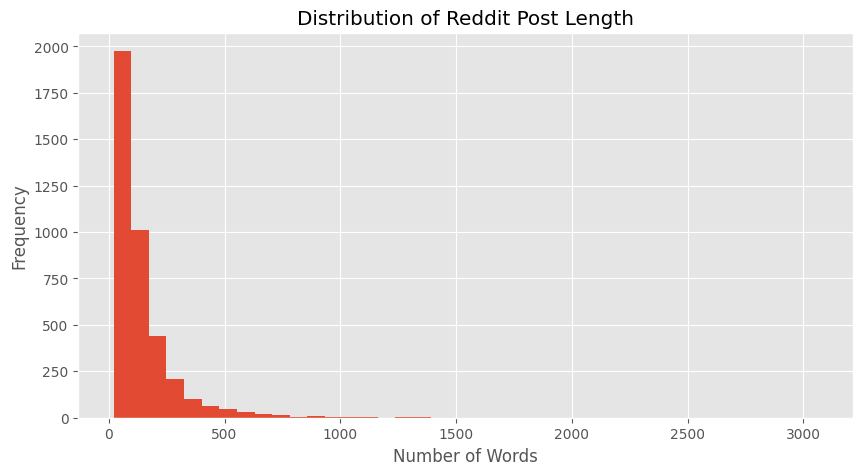

In [14]:
plt.figure(figsize=(10,5))

plt.hist(train_df["word_count"], bins=40)

plt.title("Distribution of Reddit Post Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [15]:
train_df["label"] = train_df["lonely"].apply(lambda x: x[0])

train_df["label"].value_counts()

,count
label,
1,2103
0,1840


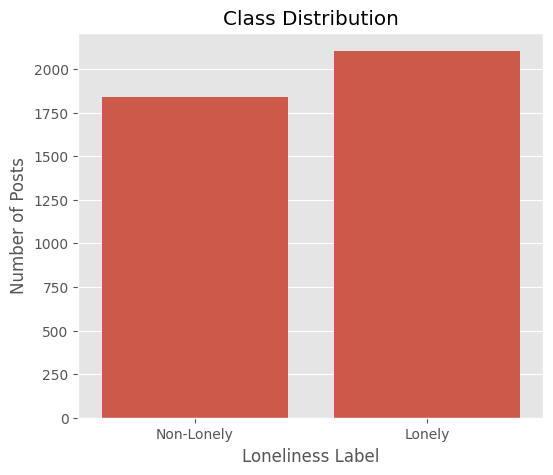

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="label",
    data=train_df
)

plt.title("Class Distribution")

plt.xlabel("Loneliness Label")

plt.ylabel("Number of Posts")

plt.xticks([0,1],["Non-Lonely","Lonely"])

plt.show()

In [17]:
train_df.groupby("label")["word_count"].mean()

,word_count
label,
0,166.383696
1,122.739895


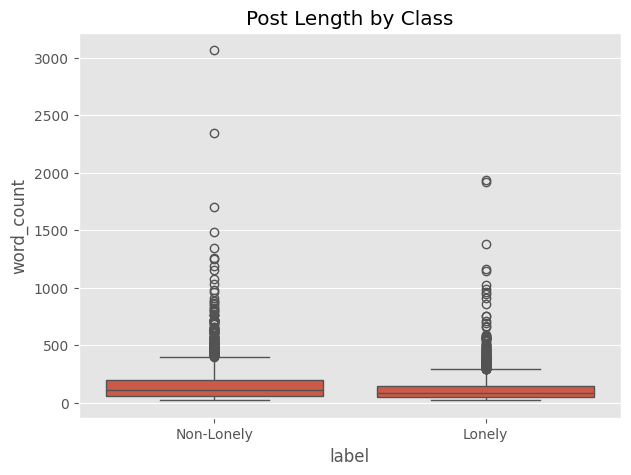

In [18]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="label",
    y="word_count",
    data=train_df
)

plt.xticks([0,1],["Non-Lonely","Lonely"])

plt.title("Post Length by Class")

plt.show()

Professional Text Preprocessing

In [19]:
!pip install -q spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 39.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [20]:
import re
import string
import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [21]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"u\/\w+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [22]:
train_df["clean_text"] = train_df["text"].apply(clean_text)

dev_df["clean_text"] = dev_df["text"].apply(clean_text)

test_df["clean_text"] = test_df["text"].apply(clean_text)

In [23]:
def lemmatize(text):

    doc = nlp(text)

    tokens = []

    for token in doc:

        if token.is_stop:
            continue

        if len(token.text) < 3:
            continue

        if token.is_space:
            continue

        tokens.append(token.lemma_)

    return " ".join(tokens)

In [24]:
train_df["processed_text"] = train_df["clean_text"].apply(lemmatize)

dev_df["processed_text"] = dev_df["clean_text"].apply(lemmatize)

test_df["processed_text"] = test_df["clean_text"].apply(lemmatize)

In [25]:
for i in range(3):

    print("="*80)

    print("ORIGINAL\n")
    print(train_df.loc[i, "text"])

    print("\n")

    print("PROCESSED\n")
    print(train_df.loc[i, "processed_text"])

    print("\n")

ORIGINAL

Should I transfer? Other than the fact that the food sucks, there isn't much of a social life here, and there really isn't a college town. I don't have many friends in the two years that I've been here. Im not a partier but I'd still like to find people to do stuff with. But it's like here if you aren't in Greek Life then you are screwed. I tried greek and I hated it. However,  I am really interested in transferring because of academics. I'm a psychology major and I want to go to grad school. I want to take neuropsychology classes, which they offer at Rutgers (a larger school) compared to my small public college. We don't have many research labs at our school or a wide variety of classes to pick from. Is leaving worth it academically for 5 classes and possibly more research opportunities? The school id be transferring to is bigger and more competitive so the classes could be harder there and they could have more people trying to get into labs. Does it make a difference if I t

In [26]:
empty_docs = (train_df["processed_text"].str.len() == 0).sum()

print("Empty processed documents:", empty_docs)

Empty processed documents: 0


In [27]:
train_df.to_csv("/content/train_processed.csv", index=False)

dev_df.to_csv("/content/dev_processed.csv", index=False)

test_df.to_csv("/content/test_processed.csv", index=False)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


Feature Engineering (TF-IDF)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [29]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.90
)

In [30]:
X_train = tfidf.fit_transform(train_df["processed_text"])

X_dev = tfidf.transform(dev_df["processed_text"])

X_test = tfidf.transform(test_df["processed_text"])

print("Training Shape :", X_train.shape)
print("Validation Shape:", X_dev.shape)
print("Test Shape :", X_test.shape)

Training Shape : (3943, 6982)
Validation Shape: (1126, 6982)
Test Shape : (564, 6982)


In [31]:
y_train = train_df["label"]

dev_df["label"] = dev_df["lonely"].apply(lambda x: x[0])
test_df["label"] = test_df["lonely"].apply(lambda x: x[0])

y_dev = dev_df["label"]
y_test = test_df["label"]

print(y_train.value_counts())

label
1    2103
0    1840
Name: count, dtype: int64


In [32]:
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 6982


In [33]:
feature_names = np.array(tfidf.get_feature_names_out())

idf_scores = tfidf.idf_

top_idx = np.argsort(idf_scores)[:20]

top_words = pd.DataFrame({
    "Word": feature_names[top_idx],
    "IDF Score": idf_scores[top_idx]
})

top_words

,Word,IDF Score
0,like,1.811437
1,feel,1.954143
2,want,1.980829
3,know,2.004778
4,time,2.120659
5,friend,2.174985
6,go,2.179099
7,people,2.227230
8,year,2.257974
9,think,2.314870


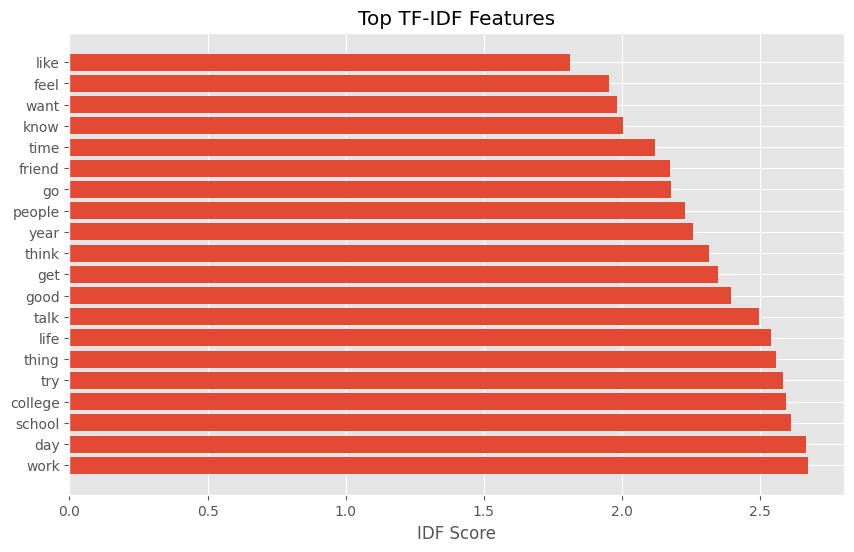

In [34]:
import matplotlib.pyplot as plt

top_plot = top_words.sort_values("IDF Score", ascending=False)

plt.figure(figsize=(10,6))

plt.barh(top_plot["Word"], top_plot["IDF Score"])

plt.title("Top TF-IDF Features")

plt.xlabel("IDF Score")

plt.show()

In [35]:
non_zero = X_train.count_nonzero()

total = X_train.shape[0] * X_train.shape[1]

sparsity = 100 * (1 - non_zero / total)

print(f"Sparsity of TF-IDF Matrix: {sparsity:.2f}%")

Sparsity of TF-IDF Matrix: 99.33%


Machine Learning Models

In [36]:
!pip install -q xgboost

In [37]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

In [38]:
results = []

def evaluate_model(model, name):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc = roc_auc_score(y_test, prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

    print("="*60)
    print(name)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc:.4f}")

    fig, ax = plt.subplots(1,3, figsize=(18,5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        ax=ax[0],
        colorbar=False
    )

    ax[0].set_title("Confusion Matrix")

    RocCurveDisplay.from_predictions(
        y_test,
        prob,
        ax=ax[1]
    )

    ax[1].set_title("ROC Curve")

    PrecisionRecallDisplay.from_predictions(
        y_test,
        prob,
        ax=ax[2]
    )

    ax[2].set_title("Precision-Recall Curve")

    plt.show()

Logistic Regression

Logistic Regression
Accuracy : 0.9450
Precision: 0.9570
Recall   : 0.9414
F1 Score : 0.9491
ROC AUC  : 0.9831


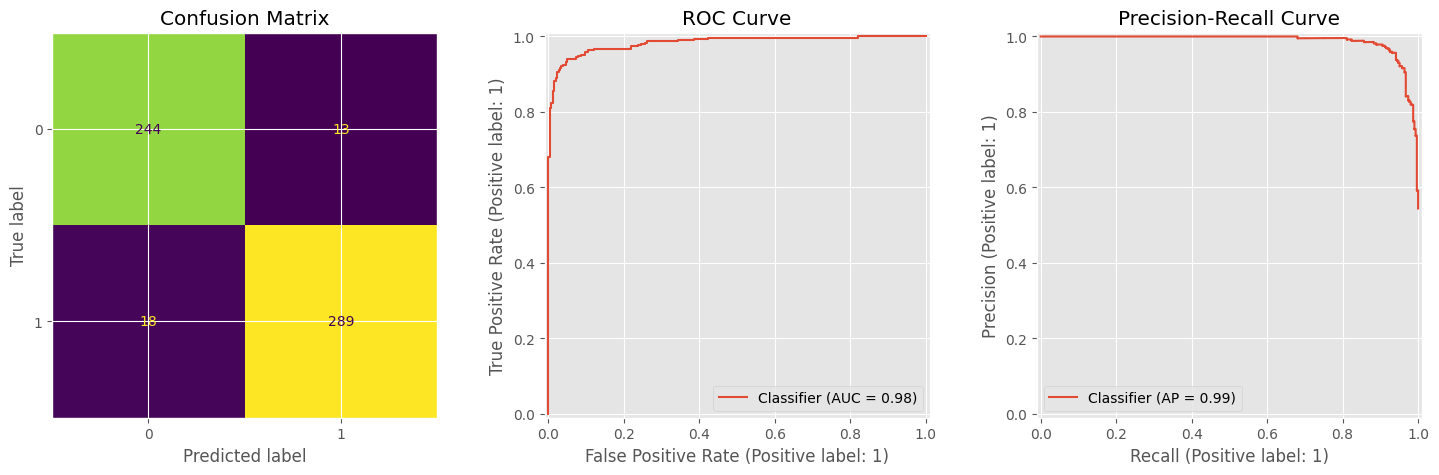

In [39]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

evaluate_model(lr,"Logistic Regression")

Random Forest

Random Forest
Accuracy : 0.9238
Precision: 0.9521
Recall   : 0.9055
F1 Score : 0.9282
ROC AUC  : 0.9807


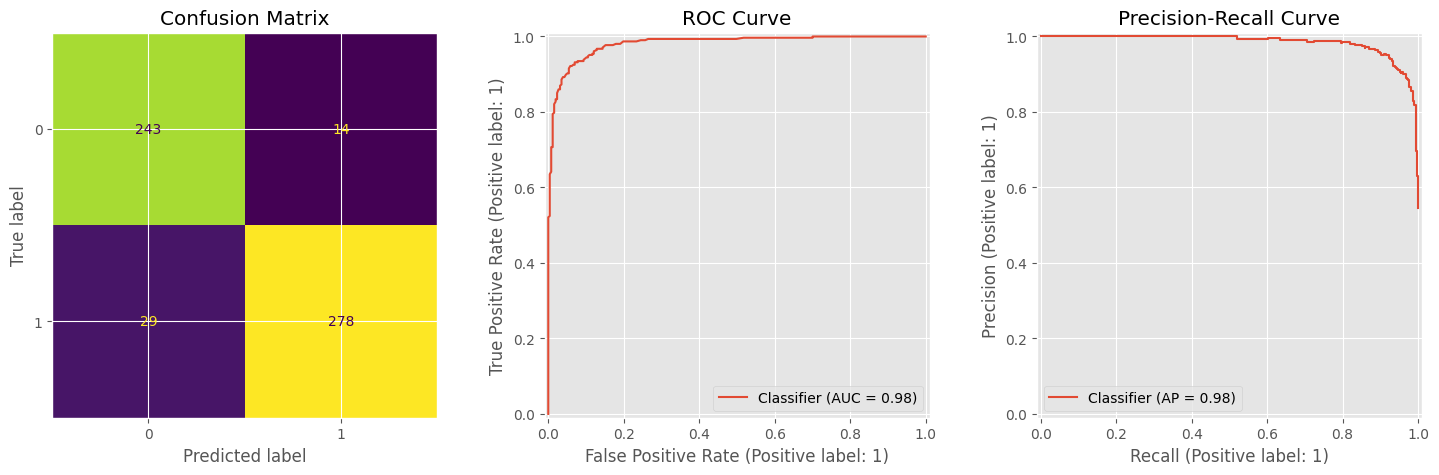

In [40]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

evaluate_model(rf,"Random Forest")

XGBoost

XGBoost
Accuracy : 0.9255
Precision: 0.9402
Recall   : 0.9218
F1 Score : 0.9309
ROC AUC  : 0.9809


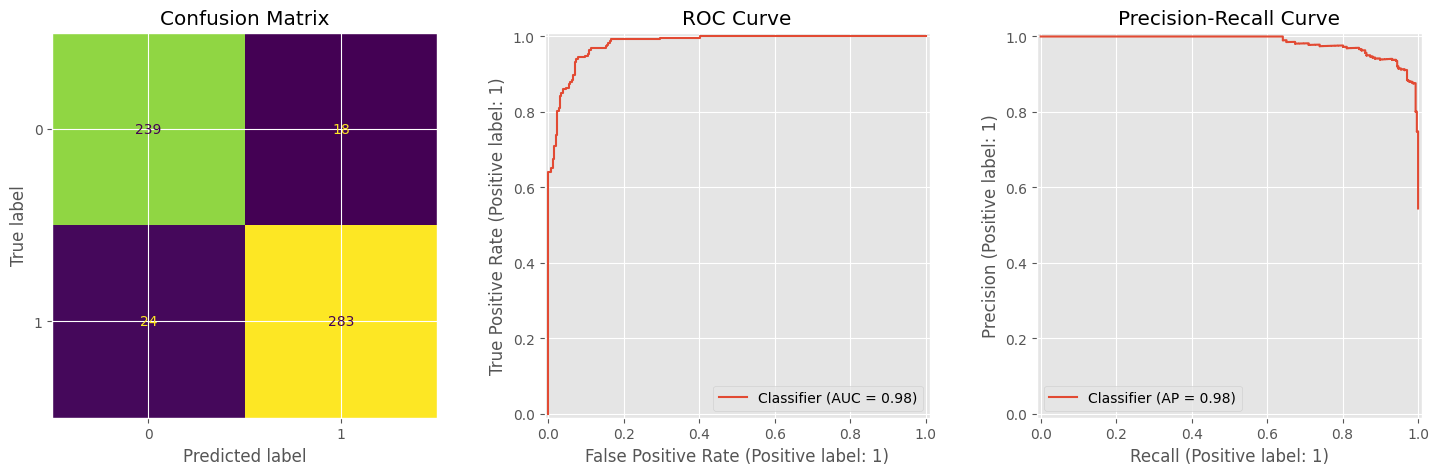

In [41]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

evaluate_model(xgb,"XGBoost")

Final Comparison Table

In [42]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.945035,0.956954,0.941368,0.949097,0.983080
2,XGBoost,0.925532,0.940199,0.921824,0.930921,0.980874
1,Random Forest,0.923759,0.952055,0.905537,0.928214,0.980716


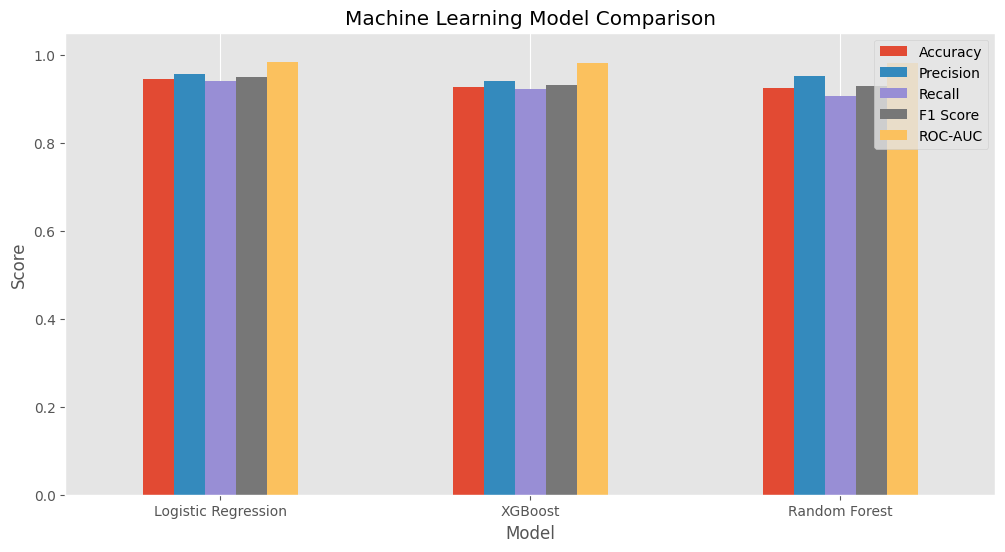

In [43]:
results_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.ylim(0,1.05)

plt.title("Machine Learning Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

Transformer Model Development (DistilBERT)

In [44]:
!pip install -q transformers datasets accelerate evaluate

In [45]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [47]:
train_df["label"] = train_df["lonely"].apply(lambda x: x[0])

dev_df["label"] = dev_df["lonely"].apply(lambda x: x[0])

test_df["label"] = test_df["lonely"].apply(lambda x: x[0])

In [48]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

In [49]:
def tokenize(batch):

    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

In [50]:
train_dataset = Dataset.from_pandas(
    train_df[["text","label"]]
)

dev_dataset = Dataset.from_pandas(
    dev_df[["text","label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["text","label"]]
)

In [51]:
train_dataset = train_dataset.map(tokenize, batched=True)

dev_dataset = dev_dataset.map(tokenize, batched=True)

test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/3943 [00:00<?, ? examples/s]

Map:   0%|          | 0/1126 [00:00<?, ? examples/s]

Map:   0%|          | 0/564 [00:00<?, ? examples/s]

In [52]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

dev_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

In [53]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tune DistilBERT

In [ ]:
!pip uninstall -y torchvision
!pip install -q torchvision==0.19.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 MB 6.2 MB/s eta 0:00:00


In [55]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from transformers import TrainingArguments, Trainer
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    probabilities = torch.nn.functional.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)
    roc_auc = roc_auc_score(labels, probabilities)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [60]:
training_args = TrainingArguments(
    output_dir="/content/distilbert_temp",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

In [61]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics
)

In [62]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.087942,0.167843,0.959147,0.956376,0.966102,0.961214,0.992047
2,0.055547,0.179494,0.962700,0.955150,0.974576,0.964765,0.993159


TrainOutput(global_step=494, training_loss=0.06156902588330782, metrics={'train_runtime': 214.6628, 'train_samples_per_second': 36.737, 'train_steps_per_second': 2.301, 'total_flos': 522318952900608.0, 'train_loss': 0.06156902588330782, 'epoch': 2.0})

Evaluate DistilBERT on Test Data

In [63]:
test_predictions = trainer.predict(test_dataset)

logits = test_predictions.predictions
y_true = test_predictions.label_ids

y_pred = np.argmax(logits, axis=1)

y_prob = torch.nn.functional.softmax(
    torch.tensor(logits),
    dim=1
)[:, 1].numpy()

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

distilbert_results = {
    "Model": "DistilBERT",
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred),
    "Recall": recall_score(y_true, y_pred),
    "F1 Score": f1_score(y_true, y_pred),
    "ROC-AUC": roc_auc_score(y_true, y_prob)
}

distilbert_results

{'Model': 'DistilBERT',
 'Accuracy': 0.9769503546099291,
 'Precision': 0.9772727272727273,
 'Recall': 0.9804560260586319,
 'F1 Score': 0.9788617886178862,
 'ROC-AUC': np.float64(0.9969834852152752)}

Explainable AI (SHAP)

In [65]:
!pip install -q shap

In [71]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
print(lr)
print(X_train.shape)
print(X_test.shape)

LogisticRegression(max_iter=1000, random_state=42)
(3943, 6982)
(564, 6982)


In [73]:
explainer = shap.LinearExplainer(
    lr,
    X_train
)

In [74]:
X_sample = X_test[:200]

In [75]:
shap_values = explainer.shap_values(X_sample)

In [76]:
feature_names = tfidf.get_feature_names_out()

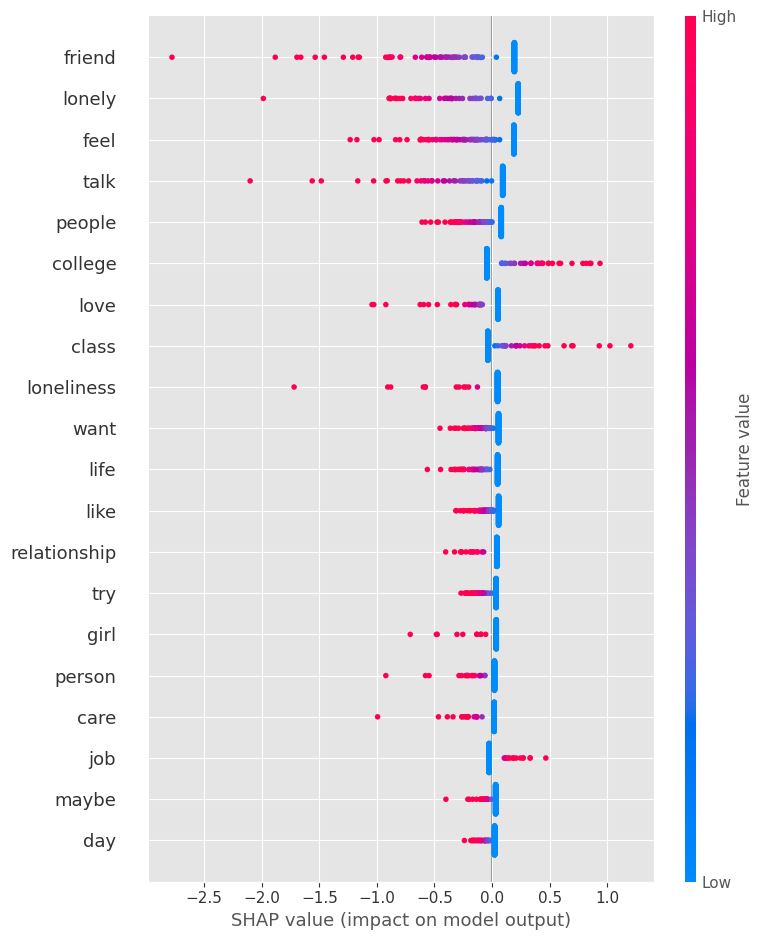

In [77]:
shap.summary_plot(
    shap_values,
    X_sample.toarray(),
    feature_names=feature_names,
    max_display=20
)

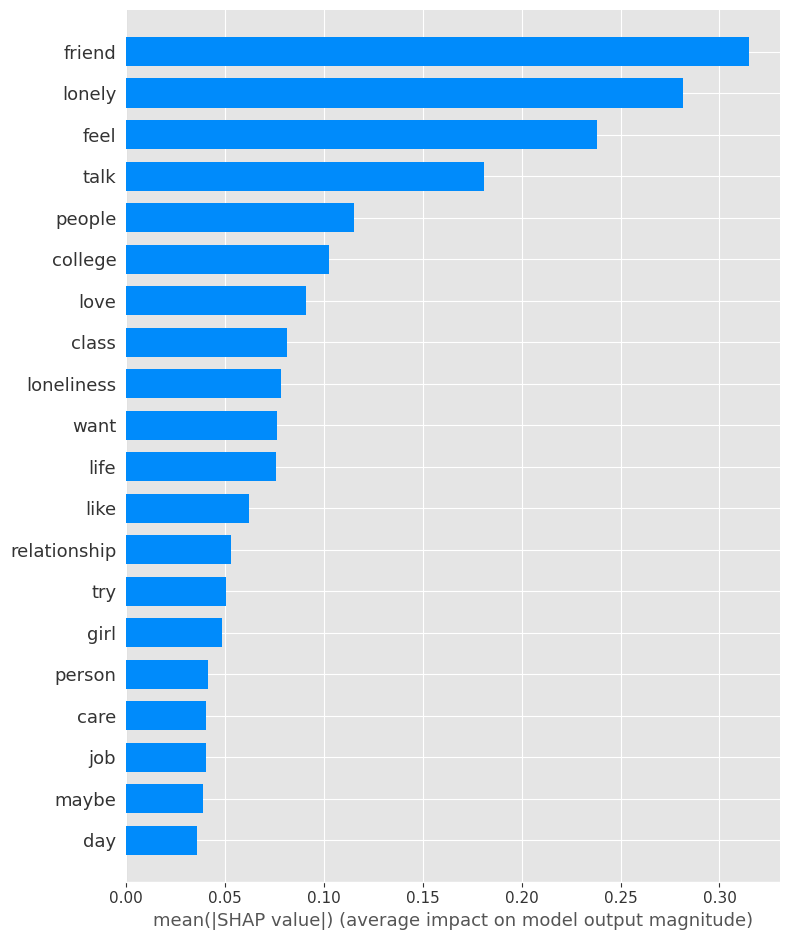

In [78]:
shap.summary_plot(
    shap_values,
    X_sample.toarray(),
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

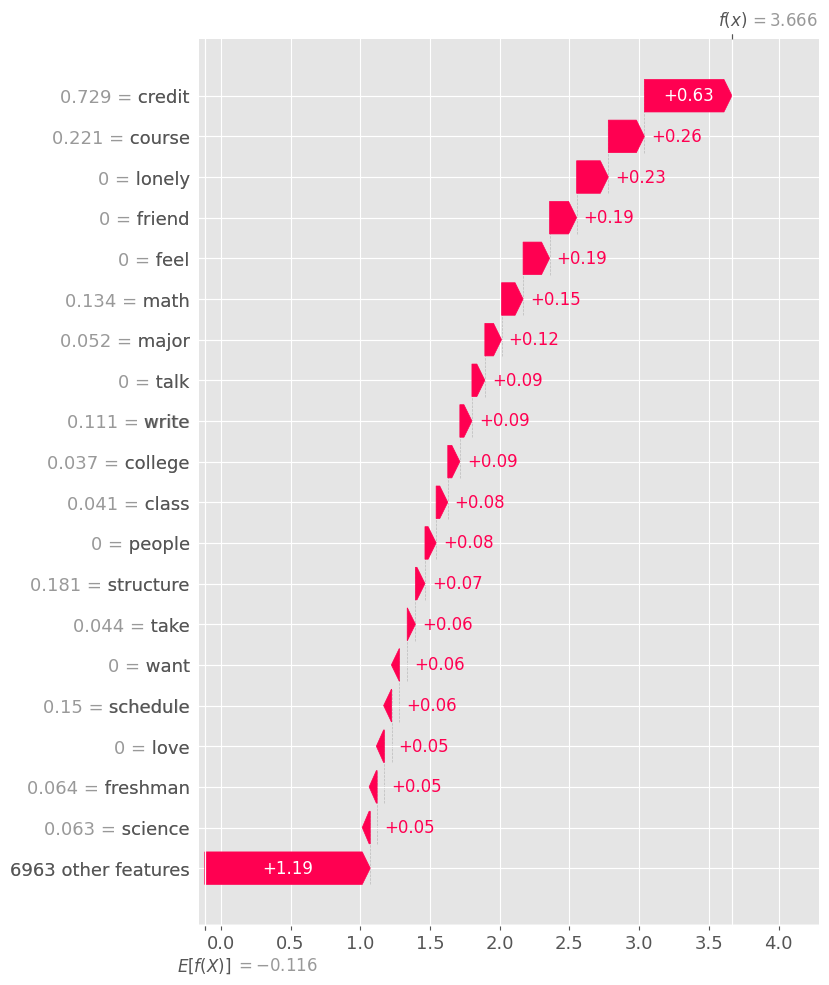

In [79]:
index = 0

explanation = shap.Explanation(
    values=shap_values[index],
    base_values=explainer.expected_value,
    data=X_sample[index].toarray()[0],
    feature_names=feature_names
)

shap.plots.waterfall(explanation, max_display=20)

In [80]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_ABS_SHAP": mean_abs_shap
}).sort_values(by="Mean_ABS_SHAP", ascending=False)

shap_importance.head(20)

,Feature,Mean_ABS_SHAP
1975,friend,0.314854
3611,lonely,0.281635
1732,feel,0.237996
5832,talk,0.181186
4401,people,0.115095
800,college,0.102495
3729,love,0.090760
709,class,0.081501
3605,loneliness,0.078553
6539,want,0.076306


In [81]:
shap_importance.to_csv("/content/shap_feature_importance.csv", index=False)

print("SHAP feature importance saved successfully.")

SHAP feature importance saved successfully.


DistilBERT evaluation plot

<Figure size 600x600 with 0 Axes>

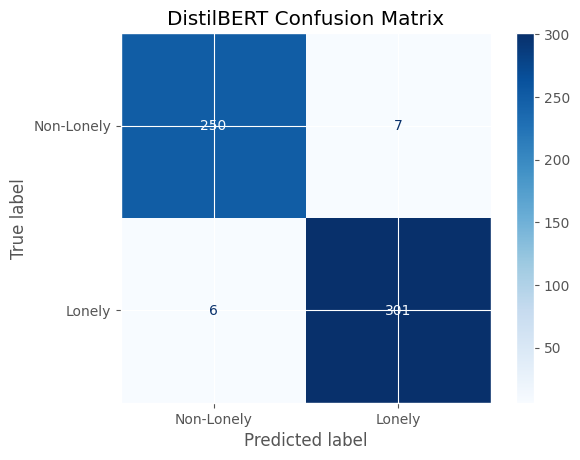

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Lonely","Lonely"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("DistilBERT Confusion Matrix")
plt.show()

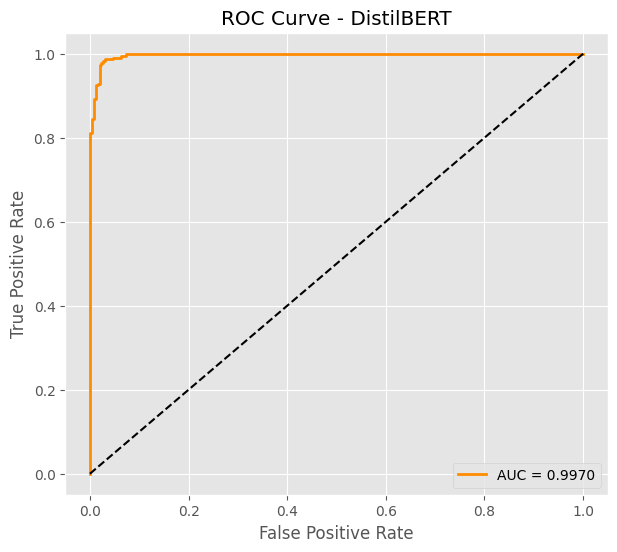

In [83]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr,
         color="darkorange",
         lw=2,
         label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DistilBERT")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

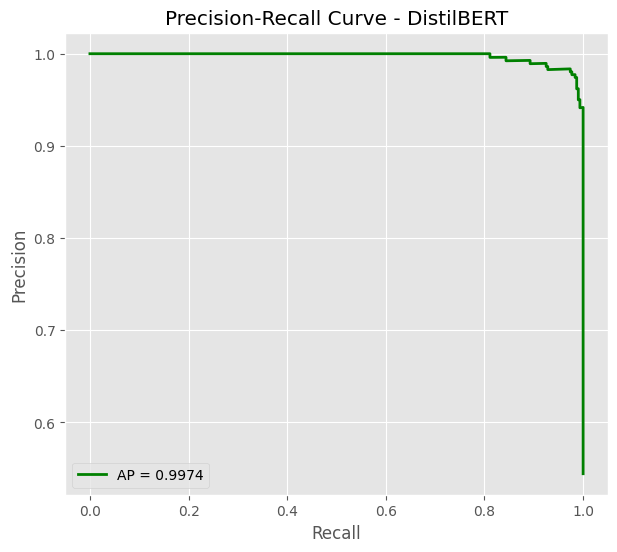

In [84]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision, recall, _ = precision_recall_curve(
    y_true,
    y_prob
)

ap = average_precision_score(y_true, y_prob)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    lw=2,
    color="green",
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - DistilBERT")
plt.legend()
plt.grid(True)

plt.show()

In [85]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-Lonely","Lonely"]
))

              precision    recall  f1-score   support

  Non-Lonely       0.98      0.97      0.97       257
      Lonely       0.98      0.98      0.98       307

    accuracy                           0.98       564
   macro avg       0.98      0.98      0.98       564
weighted avg       0.98      0.98      0.98       564



In [86]:
import pandas as pd

evaluation = pd.DataFrame([{
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred),
    "Recall": recall_score(y_true, y_pred),
    "F1 Score": f1_score(y_true, y_pred),
    "ROC-AUC": roc_auc_score(y_true, y_prob)
}])

evaluation.to_csv(
    "/content/distilbert_evaluation.csv",
    index=False
)

evaluation

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.97695,0.977273,0.980456,0.978862,0.996983


Error Analysis: Misclassified Posts

In [87]:
error_df = test_df.copy()

error_df["true_label"] = y_true
error_df["predicted_label"] = y_pred
error_df["lonely_probability"] = y_prob
error_df["correct"] = error_df["true_label"] == error_df["predicted_label"]

misclassified = error_df[error_df["correct"] == False]

print("Total misclassified:", len(misclassified))
misclassified[["text", "true_label", "predicted_label", "lonely_probability"]].head(10)

Total misclassified: 13


,text,true_label,predicted_label,lonely_probability
5,Anyone else have their shit together but are j...,1,0,0.002197
16,Allergies are keeping me awake; I'm sweaty and...,1,0,0.147721
72,Have you ever used a professional cuddling ser...,0,1,0.998514
108,Feeling pretty lost right now Does anyone else...,1,0,0.002681
110,Merry Christmas everyone hope you have a great...,0,1,0.995558
152,Dating thread? I was thinking of making a thre...,1,0,0.014178
204,Yo guys y gals. My friend said the funniest fu...,1,0,0.003031
255,How often do you socialize IRL? Not online but...,0,1,0.998905
304,My coworker hugged me today and it's the best ...,0,1,0.997446
319,Anyone in Dubai? Looking to meet with a guy st...,0,1,0.995436


In [88]:
misclassified.to_csv("/content/distilbert_misclassified_samples.csv", index=False)

print("Misclassified samples saved.")

Misclassified samples saved.


Confidence Score Analysis

In [89]:
error_df["confidence"] = np.where(
    error_df["predicted_label"] == 1,
    error_df["lonely_probability"],
    1 - error_df["lonely_probability"]
)

error_df[["confidence"]].describe()

,confidence
count,564.000000
mean,0.995298
std,0.028630
min,0.653480
25%,0.999121
50%,0.999391
75%,0.999461
max,0.999577


Plot Confidence Distribution

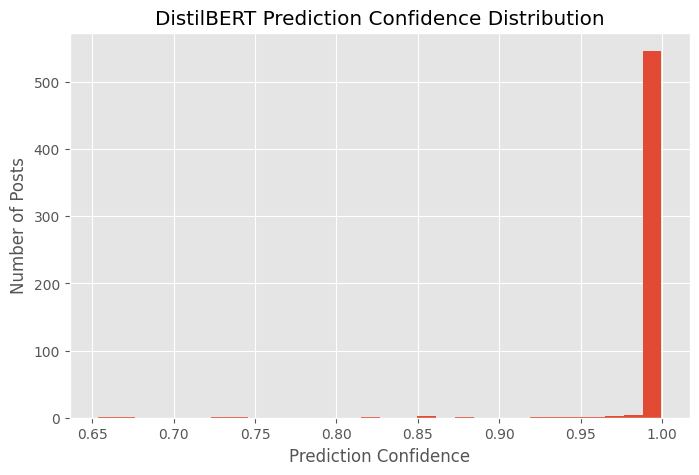

In [90]:
plt.figure(figsize=(8,5))

plt.hist(error_df["confidence"], bins=30)

plt.title("DistilBERT Prediction Confidence Distribution")
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Posts")

plt.show()

Low-Confidence Predictions

In [91]:
low_confidence = error_df.sort_values("confidence").head(10)

low_confidence[["text", "true_label", "predicted_label", "confidence", "lonely_probability"]]

,text,true_label,predicted_label,confidence,lonely_probability
243,Rant Okay I'm 21(F) from Scotland. I feel like...,1,1,0.653480,0.653480
441,"When the night comes After a break up, and whe...",0,1,0.669374,0.669374
177,[Academic Research] Participants needed for re...,1,1,0.729209,0.729209
444,Do all of you have a best friend? Wether its a...,1,0,0.745343,0.254657
161,"Anyone from the Fleurieu Peninsula, SA? I'm su...",0,0,0.815978,0.184022
16,Allergies are keeping me awake; I'm sweaty and...,1,0,0.852279,0.147721
437,"Any success stories happen from the ""make a fr...",0,1,0.858101,0.858101
505,I want to die but I want to get help I want to...,0,0,0.883797,0.116203
534,A rant because I dont know where else to post ...,1,1,0.926710,0.926710
299,My doctor told me I have depression today Hone...,1,1,0.940015,0.940015


Final Model Comparison Table

In [92]:
final_results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.945035,
        "Precision": 0.956954,
        "Recall": 0.941368,
        "F1 Score": 0.949097,
        "ROC-AUC": 0.983080
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.923759,
        "Precision": 0.952055,
        "Recall": 0.905537,
        "F1 Score": 0.928214,
        "ROC-AUC": 0.980716
    },
    {
        "Model": "XGBoost",
        "Accuracy": 0.925532,
        "Precision": 0.940199,
        "Recall": 0.921824,
        "F1 Score": 0.930921,
        "ROC-AUC": 0.980874
    },
    {
        "Model": "DistilBERT",
        "Accuracy": 0.976950,
        "Precision": 0.977273,
        "Recall": 0.980456,
        "F1 Score": 0.978862,
        "ROC-AUC": 0.996983
    }
])

final_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.945035,0.956954,0.941368,0.949097,0.983080
1,Random Forest,0.923759,0.952055,0.905537,0.928214,0.980716
2,XGBoost,0.925532,0.940199,0.921824,0.930921,0.980874
3,DistilBERT,0.976950,0.977273,0.980456,0.978862,0.996983


In [93]:
final_results_df.to_csv("/content/final_model_comparison.csv", index=False)

print("Final model comparison saved.")

Final model comparison saved.


Final Prediction Function

In [94]:
def predict_loneliness(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {key: value.to(model.device) for key, value in inputs.items()}

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        prediction = torch.argmax(probs, dim=1).item()
        confidence = probs[0][prediction].item()

    label = "Lonely" if prediction == 1 else "Non-Lonely"

    return {
        "Prediction": label,
        "Confidence": round(confidence, 4),
        "Lonely Probability": round(probs[0][1].item(), 4)
    }

In [95]:
sample_text = "I feel alone and I do not have anyone to talk to."

predict_loneliness(sample_text)

{'Prediction': 'Non-Lonely',
 'Confidence': 0.9994,
 'Lonely Probability': 0.0006}

In [96]:
sample_text = "I had a great day with my friends and family."

predict_loneliness(sample_text)

{'Prediction': 'Non-Lonely',
 'Confidence': 0.9419,
 'Lonely Probability': 0.0581}